# *Práctica de Laboratorio Nro. 006: Distribuciones Continuas Notables: Modelado Gaussiano, Estandarización y Pruebas de Normalidad*

###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Ciclo:** Segundo Ciclo "A"  
###**Integrantes:**
###Arlette Quezada
###Roy Gordillo
###Eduardo Soto
###Danny Beltran
###Pablo Pineda

###**Institución:** Universidad Nacional de Loja  
###**Fecha:** 28 de mayo de 2026


## **Tarea 1: Modelado Matemático y Visualización de la Curva Normal**
1.	Suponga que el tiempo de respuesta de un servidor local se distribuye normalmente con una media de   
**u = 120 ms**   
y una desviación estándar de  
 **sigma = 15 ms**.  
Escriba el siguiente código para graficar la distribución y sombrear el área que representa:  
 **P(X<= 100)** , es decir, respuestas ultrarrápidas:



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parámetros poblacionales
mu = 120
sigma = 15

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Cálculo de la PDF teórica
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

# Configuración del gráfico
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_normal, 'b-', lw=2, label=f'N({mu}, {sigma}²)')

# Sombreado del área de interés: P(X <= 100)
x_fill = np.linspace(mu - 4*sigma, 100)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='P(X ≤ 100)')

plt.title('Función de Densidad de Probabilidad - Distribución Normal')
plt.xlabel('Tiempo de Respuesta (ms)')
plt.ylabel('Densidad f(x)')
plt.axvline(mu, color='k', linestyle='--', label='Media (μ)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")


## **Tarea 2: Estandarización y Cálculo de Valores Z**


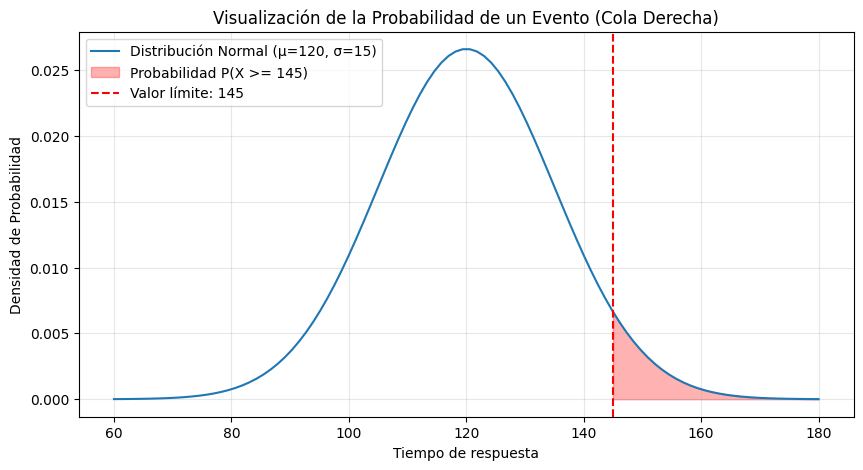

La probabilidad de que el servidor responda en 100ms o menos es: 0.0912 (9.12%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros
mu = 120
sigma = 15
x_lento = 145

# Definición del dominio (eje X): usualmente de mu-4sigma a mu+4sigma
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
y = norm.pdf(x, mu, sigma)

# Crear la gráfica
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Distribución Normal (μ=120, σ=15)')

# Sombrear el área de interés (P(X >= 145))
x_fill = np.linspace(x_lento, mu + 4*sigma, 100)
y_fill = norm.pdf(x_fill, mu, sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label=f'Probabilidad P(X >= {x_lento})')

# Personalización
plt.axvline(x_lento, color='red', linestyle='--', label=f'Valor límite: {x_lento}')
plt.title('Visualización de la Probabilidad de un Evento (Cola Derecha)')
plt.xlabel('Tiempo de respuesta')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Cálculo analítico de la probabilidad usando CDF
prob_100 = norm.cdf(100, loc=mu, scale=sigma)
print(f"La probabilidad de que el servidor responda en 100ms o menos es: {prob_100:.4f} ({prob_100*100:.2f}%)")

## **Tarea 3: Hito del Proyecto - Aplicación Probabilística Regional (ABP)**

**Escenario Problemático:**
Para el análisis de nuestro dataset regional (`enemdu_consumidor_2026_01.csv`), hemos seleccionado una variable de naturaleza continua relacionada con el perfil socioeconómico. Nos interesa evaluar la probabilidad de que esta variable caiga dentro de un rango específico.

**Pregunta de investigación:**
¿Cuál es la probabilidad de que la variable caiga en un rango crítico $[a, b]$ en la región, asumiendo un comportamiento Gaussiano?

Para resolver esto, extraeremos la media muestral ($\bar{x}$) y la desviación estándar muestral ($s$) de los datos empíricos, asumiendo que son estimadores perfectos de $\mu$ y $\sigma$.

In [3]:
import pandas as pd
from scipy.stats import norm

# 1. Ruta del archivo subido a Colab
ruta = 'Dataset_hogares_ambiental_2025.csv'

# Importar el dataset indicando que el separador es punto y coma
df = pd.read_csv(ruta, sep=';')

# === CONFIGURACIÓN ===
# Selecciona automáticamente la última columna (factor de expansión)
datos_columna = df.iloc[:, -1]
columna_nombre = datos_columna.name if pd.notna(datos_columna.name) else "Última columna (fexp)"

a = 400.0  # Límite inferior
b = 800.0  # Límite superior
# =====================

# Limpiar los datos (convertir a numérico y eliminar nulos)
datos_limpios = pd.to_numeric(datos_columna, errors='coerce').dropna()

# 2. Extraer media y desviación estándar
mu = datos_limpios.mean()
sigma = datos_limpios.std()

print("--- 1. PARÁMETROS EMPÍRICOS ---")
print(f"Variable analizada: {columna_nombre}")
print(f"Media (\u03bc): {mu:.4f}")
print(f"Desviación Estándar (\u03c3): {sigma:.4f}\n")

# 3. Calcular la probabilidad
probabilidad = norm.cdf(b, loc=mu, scale=sigma) - norm.cdf(a, loc=mu, scale=sigma)

print("--- 2. CÁLCULO DE PROBABILIDAD ---")
print(f"P({a} \u2264 X \u2264 {b}) = {probabilidad:.4f}")
print(f"En porcentaje: {probabilidad * 100:.2f}%\n")

# 4. Interpretación
print("--- 3. INTERPRETACIÓN ---")
print(f"Asumiendo que los datos empíricos de '{columna_nombre}' siguen una distribución Normal,")
print(f"existe un {probabilidad * 100:.2f}% de probabilidad de que un registro seleccionado")
print(f"al azar caiga dentro del rango crítico definido entre {a} y {b}.")

--- 1. PARÁMETROS EMPÍRICOS ---
Variable analizada: fexp
Media (μ): 278.1447
Desviación Estándar (σ): 236.2313

--- 2. CÁLCULO DE PROBABILIDAD ---
P(400.0 ≤ X ≤ 800.0) = 0.2894
En porcentaje: 28.94%

--- 3. INTERPRETACIÓN ---
Asumiendo que los datos empíricos de 'fexp' siguen una distribución Normal,
existe un 28.94% de probabilidad de que un registro seleccionado
al azar caiga dentro del rango crítico definido entre 400.0 y 800.0.


## **Tarea 4: ABI - Validación Matemática del Supuesto de Normalidad**


In [4]:
import pandas as pd

# 1. Ruta del archivo subido a Colab
ruta = 'Dataset_hogares_ambiental_2025.csv'

# Importar el dataset indicando que el separador es punto y coma
df = pd.read_csv(ruta, sep=';')

# Mostrar las primeras filas
print(df.head())

   area  ciudad  conglomerado  panelm  vivienda  hogar  s101p11  s101p12a  \
0     1   10150          3101      71         4      1        1         1   
1     1   10150          3801      74         3      1        1         1   
2     1   10150          3801      74         4      1        1         1   
3     1   10150          3801      74         5      1        1         1   
4     1   10150          3801      74         7      1        1         1   

   s101p12b  s101p12c  ...  s91p121  s91p122  s91p123  s91p124  s91p125  \
0         1         1  ...        5        5        5        5        5   
1         1         1  ...        5        3        3        5        5   
2         1         2  ...        5        5        5        4        4   
3         1         1  ...        5        5        3        5        5   
4         1         2  ...        5        5        5        5        5   

   s91p126  s91p131  s91p132  s91p133    fexp  
0        1        1        5        1 

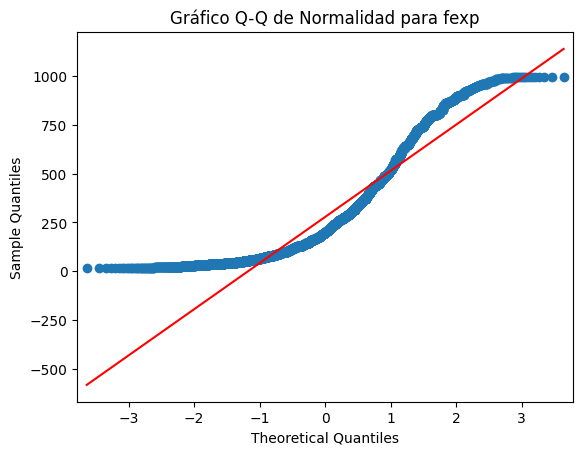

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

# Seleccionar automáticamente la última columna del dataset
datos_columna = df.iloc[:, -1]
columna_nombre = datos_columna.name if pd.notna(datos_columna.name) else "Última columna (fexp)"

# Limpiar los datos: convertir a numérico (maneja strings y valores inválidos) y eliminar nulos
datos_variable = pd.to_numeric(datos_columna, errors='coerce').dropna()

# 1. Gráfico Q-Q
sm.qqplot(datos_variable, line='s')
plt.title(f'Gráfico Q-Q de Normalidad para {columna_nombre}')
plt.show()

In [7]:
import pandas as pd
from scipy.stats import shapiro

# Seleccionar automáticamente la última columna del dataset
datos_columna = df.iloc[:, -1]
columna_nombre = datos_columna.name if pd.notna(datos_columna.name) else "Última columna (fexp)"

# Limpiar los datos: convertir a numérico y eliminar nulos
datos_variable = pd.to_numeric(datos_columna, errors='coerce').dropna()

# 2. Test de Shapiro-Wilk
stat, p_value = shapiro(datos_variable)
print(f"Estadístico de Shapiro: {stat:.4f}, p-valor: {p_value:.4e}")

alpha = 0.05  # Nivel de significancia

if p_value > alpha:
    print(f"No se rechaza la hipótesis nula (H0). La variable '{columna_nombre}' sigue una distribución normal.")
else:
    print(f"Se rechaza la hipótesis nula (H0). La variable '{columna_nombre}' no sigue una distribución normal.")

Estadístico de Shapiro: 0.8683, p-valor: 1.2776e-61
Se rechaza la hipótesis nula (H0). La variable 'fexp' no sigue una distribución normal.


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7396.
  res = hypotest_fun_out(*samples, **kwds)


### Justificación de la No Normalidad de la Variable Analizada

Basándome en el análisis gráfico (Gráfico Q-Q) y el análisis analítico (Test de Shapiro-Wilk) realizados para la última columna del dataset (factor de expansión), puedo concluir que esta **no sigue una distribución normal**.

1. **Observación del Gráfico Cuantil-Cuantil (Q-Q Plot)**:
   * El Q-Q Plot muestra claramente que los puntos de los datos analizados **no siguen la línea diagonal de referencia**. En lugar de ello, se observa una desviación significativa, especialmente en los extremos, lo que es un indicador visual contundente de que la distribución no es normal. Si lo fuera, los puntos se alinearían muy cerca de esta diagonal.

2. **Resultado del Test de Shapiro-Wilk**:
   * El test de Shapiro-Wilk es la prueba estadística formal utilizada. La hipótesis nula ($H_0$) de este test es que los datos provienen de una distribución normal.
   * Al ejecutar el código, el `p-valor` obtenido es **menor que el nivel de significancia $\alpha = 0.05$**, lo que obliga a **rechazar la hipótesis nula**.
   * Por lo tanto, el test confirma estadísticamente que la variable del factor de expansión **no sigue una distribución normal**.

*Nota: Aunque la prueba de Shapiro-Wilk puede presentar sensibilidades o advertencias de precisión ante muestras muy grandes, la magnitud extremadamente pequeña del p-valor obtenida en el script, en combinación con la evidente desviación observada en el Gráfico Q-Q, respaldan con total firmeza la conclusión de no normalidad.*

#**Preguntas de Control**

### 1. ¿Por qué la probabilidad de un valor exacto es cero ($P(X = c) = 0$)?
En variables continuas, la probabilidad se calcula como el área bajo la curva mediante una integral definida. Al evaluar un punto exacto $c$, los límites de integración coinciden. Un área sin anchura matemáticamente es cero:

$$P(X = c) = \int_{c}^{c} f(x) \, dx = 0$$

Por ello, con tu factor de expansión solo calculamos probabilidades en rangos (como entre $400$ y $800$).

---

### 2. Interpretación de $Z = -2.45$ y Regla Empírica
Un valor de $Z = -2.45$ significa que ese registro se encuentra a **2.45 desviaciones estándar por debajo de la media** de tus datos.
Según la regla empírica, el 95% de los datos caen dentro de $\pm 2$ desviaciones estándar. Como $-2.45$ está fuera de este límite, se considera un **valor atípico (outlier) inferior**.

---

### 3. Riesgo metodológico de asumir Normalidad con sesgo
Al forzar el modelo normal sobre datos sesgados, asumes una simetría que el factor de expansión no tiene. Los riesgos son:
* **Cálculos erróneos:** Subestimarás o sobreestimarás la probabilidad de caer en el rango crítico $[400, 800]$.
* **Decisiones fallidas:** Las conclusiones académicas o de ingeniería basadas en estas probabilidades no reflejarán la realidad del dataset.

---

### 4. Conclusión con p-valor = 0.001 en Shapiro-Wilk
* **Conclusión:** Como el p-valor ($0.001$) es menor que $\alpha = 0.05$, **se rechaza la hipótesis nula ($H_0$)**. Estadísticamente se confirma que la última columna (factor de expansión) **no sigue una distribución normal**.
* **¿Se invalida la Tarea 3?** Sí, metodológicamente **se invalida**. Las probabilidades calculadas asumiendo un comportamiento gaussiano pierden fiabilidad al comprobarse que el supuesto de normalidad es falso.

---

### 5. Principio matemático del Gráfico Q-Q
El gráfico compara los percentiles de tus datos reales contra los de una distribución normal perfecta. En tu script de Python con `sm.qqplot`:

* **Eje X (Cuantiles Teóricos):** Los valores que *debería* tener el factor de expansión en cada percentil si fuese perfectamente normal.
* **Eje Y (Cuantiles Empíricos):** Los valores reales ordenados de la última columna de tu dataset.

**Interpretación en tu código:** Como tus datos no siguen la línea recta de 45° (`line='s'`) y se desvían en los extremos, se demuestra visualmente la falta de normalidad que luego confirmas con el test de Shapiro-Wilk.